# Báo Cáo Triển Khai: Linear Regression (Hồi Quy Tuyến Tính)

## 1. Đặt Vấn Đề và Thiết Lập Mô Hình
Linear Regression là thuật toán giải quyết các bài toán có đầu ra là giá trị thực. Giả sử cần dự đoán giá trị $y$ (ví dụ: giá nhà) dựa trên tập dữ liệu đầu vào $X$ (ví dụ: diện tích). 

Mô hình dự đoán có dạng một phương trình đường thẳng:
$$\hat{y}_i = w_1 x_i + w_0$$
Trong đó, $w_1$ là hệ số góc (trọng số đặc trưng) và $w_0$ là hệ số tự do (bias). Bài toán cốt lõi là tìm ra bộ tham số $(w_0, w_1)$ sao cho đường thẳng này khớp nhất với tập dữ liệu quan sát được.

Dưới dạng ma trận tổng quát cho $N$ điểm dữ liệu và $m$ đặc trưng, ta có:
$$X \in \mathbb{R}^{N \times (m+1)}, \quad w \in \mathbb{R}^{(m+1) \times 1}, \quad y \in \mathbb{R}^{N \times 1}$$
$$\hat{y} = Xw$$

## 2. Hàm Mất Mát (Loss Function)
Để đánh giá độ tốt của mô hình, ta cần một hàm mất mát để tính toán sự chênh lệch giữa giá trị dự báo $\hat{y}$ và giá trị thực tế $y$. Hai hàm phổ biến nhất là:

* **Mean Absolute Error (MAE - L1 Loss)**: Tính tổng trị tuyệt đối của hiệu số. L1 Loss hoạt động cực kỳ hiệu quả và ít bị bóp méo khi tập dữ liệu có chứa các điểm nhiễu ngoại lai (outliers).
* **Mean Square Error (MSE - L2 Loss)**: Tính tổng bình phương của hiệu số. MSE dễ tính đạo hàm hơn nhưng lại nhạy cảm với outliers vì khi sai số $e > 1$, giá trị $e^2$ sẽ tăng vọt theo cấp số nhân, khiến mô hình bị kéo lệch về phía điểm nhiễu.

Trong bài toán này, ta sử dụng L2 Loss kết hợp chia trung bình:
$$J(w) = \frac{1}{2N} \sum_{i=1}^N (\hat{y}_i - y_i)^2 = \frac{1}{2N} ||Xw - y||_2^2$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.array([30, 32.4138, 34.8276, 37.2414, 39.6552, 42.069, 44.4828, 46.8966, 49.3103, 51.7241, 54.1379, 56.5517, 58.9655, 61.3793, 63.7931, 66.2069, 68.6207, 71.0345, 73.4483, 75.8621, 78.2759, 80.6897, 83.1034, 85.5172, 87.931, 90.3448, 92.7586, 95.1724, 97.5862, 100]).reshape(-1, 1)
y = np.array([448.524, 509.248, 535.104, 551.432, 623.418, 625.992, 655.248, 701.377, 748.918, 757.881, 831.004, 855.409, 866.707, 902.545, 952.261, 995.531, 1069.78, 1074.42, 1103.88, 1138.69, 1153.13, 1240.27, 1251.9, 1287.97, 1320.47, 1374.92, 1410.16, 1469.69, 1478.54, 1515.28]).reshape(-1, 1)

X_bar = np.hstack((np.ones((x.shape[0], 1)), x))

## 3. Tối ưu hóa bằng Gradient Descent
Mục tiêu là tìm điểm cực tiểu toàn cục của hàm mục tiêu $J(w)$. Để làm điều này, ta tính đạo hàm riêng của $J(w)$ theo từng tham số:

$$\frac{\partial J}{\partial w_0} = \sum_{i=1}^N (w_0 + w_1 x_i - y_i)$$
$$\frac{\partial J}{\partial w_1} = \sum_{i=1}^N x_i (w_0 + w_1 x_i - y_i)$$

Dựa trên đạo hàm, ta cập nhật bộ tham số ngược hướng với vector Gradient để tiến dần đến điểm cực tiểu:
$$w = w - \eta \nabla J(w)$$
Trong đó $\eta$ là hệ số học (learning rate).

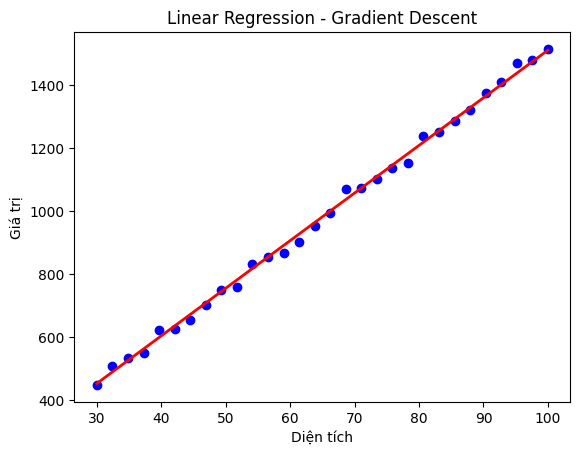

In [2]:
w = np.array([0., 1.]).reshape(-1, 1)
numOfIteration = 100
learning_rate = 0.000001
cost = np.zeros((numOfIteration, 1))

for i in range(1, numOfIteration):
    r = np.dot(X_bar, w) - y
    cost[i] = 0.5 * np.sum(r * r)
    w[0] -= learning_rate * np.sum(r)
    w[1] -= learning_rate * np.sum(np.multiply(r, x))

predict = np.dot(X_bar, w)

plt.plot((x[0][0], x[-1][0]), (predict[0][0], predict[-1][0]), 'r', linewidth=2)
plt.scatter(x, y, color='blue')
plt.xlabel('Diện tích')
plt.ylabel('Giá trị')
plt.title('Linear Regression - Gradient Descent')
plt.show()

## 4. Nghiệm chính xác bằng Đại Số Tuyến Tính (Normal Equation)
Thay vì dùng thuật toán lặp để xấp xỉ điểm cực tiểu, ta có thể tính trực tiếp nghiệm tối ưu bằng cách giải phương trình đạo hàm bằng 0. 

Thiết lập biểu thức đạo hàm ma trận:
$$\frac{\partial}{\partial w} \left( y^T y - y^T Xw - w^T X^T y + w^T X^T Xw \right) = 0$$
Rút gọn phương trình, ta tìm được ma trận trọng số tối ưu:
$$w = (X^T X)^{-1} X^T y$$
Trong trường hợp $X^T X$ không khả nghịch, ta sử dụng ma trận nghịch đảo giả (Pseudo-inverse).

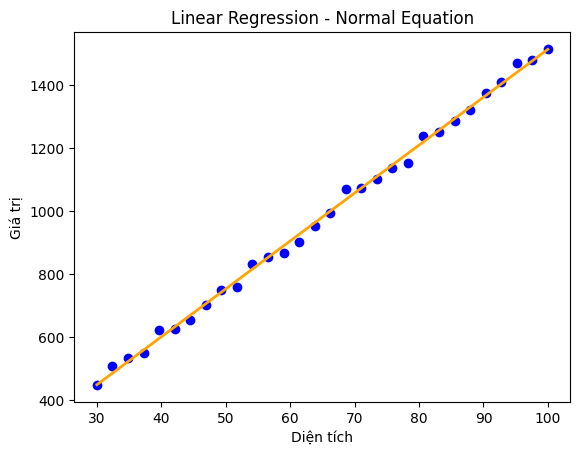

In [3]:
w_exact = np.dot(np.linalg.pinv(np.dot(X_bar.T, X_bar)), np.dot(X_bar.T, y))
predict_exact = np.dot(X_bar, w_exact)

plt.plot((x[0][0], x[-1][0]), (predict_exact[0][0], predict_exact[-1][0]), 'orange', linewidth=2)
plt.scatter(x, y, color='blue')
plt.xlabel('Diện tích')
plt.ylabel('Giá trị')
plt.title('Linear Regression - Normal Equation')
plt.show()

## 5. Triển khai bằng Scikit-Learn
Sử dụng thư viện chuyên dụng để huấn luyện mô hình. Thư viện này ngầm định áp dụng các kỹ thuật tối ưu toán học ở cấp độ nền tảng để đưa ra kết quả hội tụ nhanh chóng và chính xác.

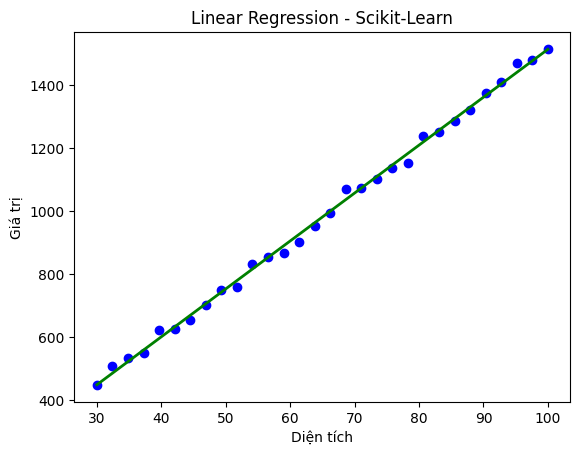

In [4]:
from sklearn.linear_model import LinearRegression

lrg = LinearRegression()
lrg.fit(x, y)
y_pred = lrg.predict(x)

plt.plot((x[0][0], x[-1][0]), (y_pred[0][0], y_pred[-1][0]), 'green', linewidth=2)
plt.scatter(x, y, color='blue')
plt.xlabel('Diện tích')
plt.ylabel('Giá trị')
plt.title('Linear Regression - Scikit-Learn')
plt.show()